# **Week 9 Applied Session: Data Transformation**

This week, we focus on the basic techniques for the data transformation. We will cover the following topics:

* 1. Data Normalisation and Tranformation
* 2. Data Discretisation
* 3. Data Sampling

## 1: Data Normalisation and Transformation

When one or more datasets affects results disproportionately, normalization or scaling gives a level playing field. In this activity, we will apply different data methods for data normalisation and transformation. We first read the dataset that is used for the first part of the analysis.

### 📌 核心概念解释
**数据标准化（Data Normalisation）**：当不同特征的量纲差异很大时，某些特征可能会不成比例地影响结果。标准化可以让所有特征在同一水平上进行比较。

**为什么需要标准化？**
- 不同特征可能有不同的量纲（如年龄 vs 收入）
- 机器学习算法往往对数值大小敏感
- 标准化可以提高算法的性能和收敛速度

In [289]:
import pandas as pd
import numpy as np

# 读取葡萄酒数据集，只选择前3列：类别标签、酒精含量、苹果酸含量
df = pd.read_csv( 'wine_data.csv', header = None, usecols = [0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']  # 重命名列
df.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [290]:
df.describe()

,Class label,Alcohol,Malic acid
count,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348
std,0.775035,0.811827,1.117146
min,1.000000,11.030000,0.740000
25%,1.000000,12.362500,1.602500
50%,2.000000,13.050000,1.865000
75%,3.000000,13.677500,3.082500
max,3.000000,14.830000,5.800000


### 💡 观察数据特点
让我们先查看数据的基本统计信息，了解不同特征的分布情况：

As we can see in the tables above, the features, Alcohol (percent/volumne) and Malic acid (g/l) are measured on different scales, so scaling is necessary prior to any comparison or combination of data.

### 🔍 数据量纲差异分析
从上面的统计表可以看出：
- **酒精含量（Alcohol）**：范围大约在 11-15%，均值约 13
- **苹果酸含量（Malic acid）**：范围大约在 0.7-5.8 g/l，均值约 2.3

这两个特征在不同的量纲上测量，如果直接用于机器学习算法，酒精含量的数值会"主导"苹果酸含量。

In [291]:
# 计算酒精含量均值与苹果酸含量均值的比值
# 这显示了两个特征之间的量纲差异有多大
df.Alcohol.mean() / df["Malic acid"].mean() # difference is factor of ~5x
# 结果约为5倍，说明酒精含量的数值明显大于苹果酸含量

np.float64(5.564503330367663)

## 1. Z-Score Normalisation (standardisation): 

We use scikit-learn linrary for standardise data (mean=0, SD=1). The class you are going to use is the <a href="http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html">StandardScaler</a> class. More reading materials can be found <a href="http://scikit-learn.org/stable/modules/preprocessing.html">here</a>. 

The task here it to standardise the values of Alcohol and Malic Acid, and append the standard variables to the DataFrame `df` as follows

### 📚 Z-Score标准化原理
**公式**: $z = \frac{x - \mu}{\sigma}$

其中：
- $x$ 是原始值
- $\mu$ 是均值
- $\sigma$ 是标准差

**效果**：标准化后的数据均值为0，标准差为1

**适用场景**：
- ✅ 数据近似服从正态分布
- ✅ 需要保持数据的相对关系
- ✅ 大多数机器学习算法的预处理

<img src="fig_1.png" alt="Smiley face" >

In [292]:
# 导入sklearn的预处理模块
from sklearn import preprocessing

In [293]:
# 步骤1：创建StandardScaler对象并拟合数据
# fit()方法计算数据的均值和标准差
std_scale = preprocessing.StandardScaler().fit(df[['Alcohol', 'Malic acid']])

# 步骤2：应用标准化转换
# transform()方法使用之前计算的均值和标准差进行标准化
df_std = std_scale.transform(df[['Alcohol', 'Malic acid']]) # an array not a df

# 显示前5行标准化后的结果（注意：这是numpy数组，不是DataFrame）
df_std[0:5]

array([[ 1.51861254, -0.5622498 ],
       [ 0.24628963, -0.49941338],
       [ 0.19687903,  0.02123125],
       [ 1.69154964, -0.34681064],
       [ 0.29570023,  0.22769377]])

In [294]:
# 将标准化后的数据添加到原DataFrame中，方便对比观察
df['Ascaled'] = df_std[:,0] # 'Ascaled' 是标准化后的酒精含量
df['MAscaled'] = df_std[:,1] # 'MAscaled' 是标准化后的苹果酸含量
df.head()

,Class label,Alcohol,Malic acid,Ascaled,MAscaled
0,1,14.23,1.71,1.518613,-0.562250
1,1,13.20,1.78,0.246290,-0.499413
2,1,13.16,2.36,0.196879,0.021231
3,1,14.37,1.95,1.691550,-0.346811
4,1,13.24,2.59,0.295700,0.227694


Now, compute and display the normalised values for both features. Let's check if they have mean of 0 and SD= 1.

### ✅ 验证标准化效果
标准化是否成功？我们需要检查：
1. **均值是否接近0**
2. **标准差是否接近1**

In [295]:
# 查看所有列的统计信息，重点关注标准化后的列
# 标准化后的列（Ascaled, MAscaled）应该均值≈0，标准差≈1
df.describe() # check that μ = 0 and σ = 1... approx

,Class label,Alcohol,Malic acid,Ascaled,MAscaled
count,178.000000,178.000000,178.000000,1.780000e+02,1.780000e+02
mean,1.938202,13.000618,2.336348,-8.382808e-16,-1.197544e-16
std,0.775035,0.811827,1.117146,1.002821e+00,1.002821e+00
min,1.000000,11.030000,0.740000,-2.434235e+00,-1.432983e+00
25%,1.000000,12.362500,1.602500,-7.882448e-01,-6.587486e-01
50%,2.000000,13.050000,1.865000,6.099988e-02,-4.231120e-01
75%,3.000000,13.677500,3.082500,8.361286e-01,6.697929e-01
max,3.000000,14.830000,5.800000,2.259772e+00,3.109192e+00


Or you can print out values:

In [296]:
# 更精确地打印标准化后的均值和标准差
print('Mean after standardisation:\nAlcohol = {:.2f}, Malic acid = {:.2f}'
      .format(df_std[:,0].mean(), df_std[:,1].mean()))
print('\nStandard deviation after standardisation:\nAlcohol = {:.2f}, Malic acid = {:.2f}'
      .format(df_std[:,0].std(), df_std[:,1].std()))

# 💡 理想情况下，均值应该是0.00，标准差应该是1.00

Mean after standardisation:
Alcohol = -0.00, Malic acid = -0.00

Standard deviation after standardisation:
Alcohol = 1.00, Malic acid = 1.00


#### Discussion: Comparing the variables before and after
In order to investigate how the normalization actually affect the data, we can visualize the data by plotting the variable values.

Try to answer these questions below after observing the plots:
- Does the shape of variables changes?
- Why the normalized data is positioned differently comparing with the un-normalised ones?
- Do you think normalization changes the signal/knowledge hidden in the variable?

### 🤔 思考题解答

**Q1: 变量的形状是否改变？**
**A1**: 不会改变。标准化是**线性变换**，只改变数据的位置和尺度，不改变分布的形状。

**Q2: 为什么标准化后的数据位置不同？**
**A2**: 因为标准化将数据**平移**到均值为0的位置，并**缩放**到标准差为1的范围。

**Q3: 标准化是否改变数据中隐藏的信号/知识？**
**A3**: **不会**。标准化保持了数据点之间的**相对关系**，只是改变了数值的表示方式。

Firstly, plot the original data, i.e., data before normalization

In [297]:
import matplotlib.pyplot as plt

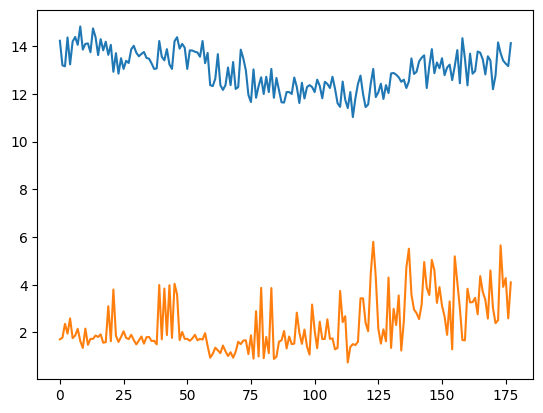

In [298]:
# 绘制原始数据的分布图
# 注意观察两个特征的数值范围差异
df["Alcohol"].plot(), df["Malic acid"].plot()
plt.show()

# 💡 观察：酒精含量在11-15范围，苹果酸在0-6范围，量纲差异明显

Now, we plot  the standardized data, and observe the range and the centre of the distribution for the standardised features.

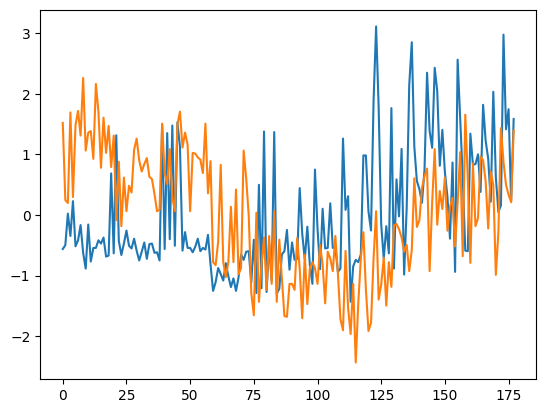

In [299]:
# 绘制标准化后的数据分布图
# 观察：现在两个特征都围绕0值分布，范围相似
df["MAscaled"].plot(), df["Ascaled"].plot()
plt.show()

# 💡 观察：标准化后，两个特征都在-3到+3的相似范围内，便于算法处理

You can see from above graphs that both original and standardized data are in the same shape but shifted.

### 📊 标准化前后对比分析
下面我们将同一特征的标准化前后版本放在同一张图中对比：

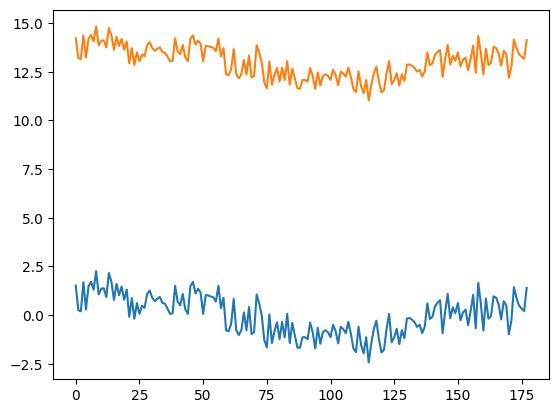

In [300]:
# 酒精含量：标准化前后对比
# 蓝色线是原始数据，橙色线是标准化后的数据
df["Ascaled"].plot(), df["Alcohol"].plot()
plt.show()

# 💡 观察：形状完全相同，只是位置和尺度不同

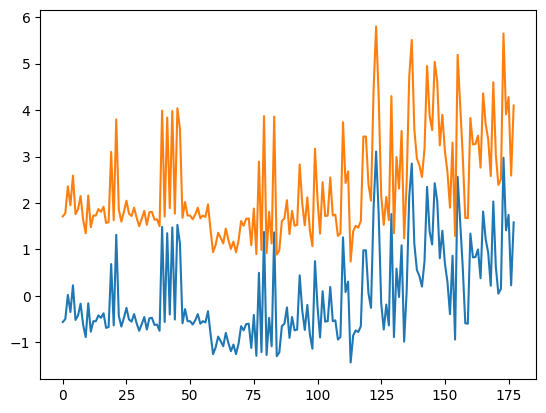

In [301]:
# 苹果酸含量：标准化前后对比
df["MAscaled"].plot(), df["Malic acid"].plot()
plt.show()

# 💡 关键结论：标准化保持了数据的相对关系和分布形状

### Task 1.2. MinMax Noramlisation:

In this section, we discuss a different type of normalization for reshaping the range of data. We process the same data we used in the previous section. We can implement this either Scikit-Learn or manually.

### 📚 Min-Max标准化原理
**公式**: $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$

**效果**：将数据缩放到[0,1]范围内

**特点**：
- ✅ 保持数据的分布形状
- ✅ 所有值都在[0,1]范围内
- ❌ 对异常值敏感
- 🎯 适用于已知数据范围的情况

#### 1.2.1 Using scikit-learn to implement:
please refer to section 4.3.1.1 "<a href="http://scikit-learn.org/stable/modules/preprocessing.html#scaling-features-to-a-range">Scaling features to a range</a>" for more detailed discussion. Similar to what you have done with the StandardScaler, here you are going to use the <a href="http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html">MinMaxScaler</a>.

In [302]:
# 使用sklearn的MinMaxScaler进行Min-Max标准化
minmax_scale = preprocessing.MinMaxScaler().fit(df[['Alcohol', 'Malic acid']])
df_minmax = minmax_scale.transform(df[['Alcohol', 'Malic acid']])

# 显示前5行结果，注意数值都在[0,1]范围内
df_minmax[0:5]

array([[0.84210526, 0.1916996 ],
       [0.57105263, 0.2055336 ],
       [0.56052632, 0.3201581 ],
       [0.87894737, 0.23913043],
       [0.58157895, 0.36561265]])

#### 1.2.2 Manually:
Of course, you can implement the Min-Max normalization according to the formulas discussed in the lecture.

### 🛠️ 手动实现Min-Max标准化
让我们手动计算来理解公式的工作原理：

Firstly, find the min and max of "df.Alcohol".

In [303]:
# 步骤1：找到酒精含量的最小值和最大值
minA = df.Alcohol.min()
maxA = df.Alcohol.max()
print(f"酒精含量范围: {minA:.2f} - {maxA:.2f}")
minA, maxA

酒精含量范围: 11.03 - 14.83


(11.03, 14.83)

Manually apply the min-max normalization to the first value of "df.Alcohol",

In [304]:
# 步骤2：手动应用Min-Max公式到第一个数值
a = df.Alcohol[0] # the first value, for practice
print(f"原始值: {a}")

# 应用Min-Max公式: (x - min) / (max - min)
mma = (a - minA) / (maxA - minA)
print(f"标准化后: {mma:.6f}")
mma

原始值: 14.23
标准化后: 0.842105


np.float64(0.8421052631578949)

and then compare the manually computed value with the one given by the MinMaxScaler above.

In [305]:
# 步骤3：与sklearn的结果对比验证
print(f"手动计算结果: {mma:.6f}")
print(f"sklearn结果: {df_minmax[0][0]:.6f}")
print(f"差异: {abs(mma - df_minmax[0][0]):.10f}")

df_minmax[0][0]

手动计算结果: 0.842105
sklearn结果: 0.842105
差异: 0.0000000000


np.float64(0.8421052631578951)

The two values should be the same.
Now, let's look at the normalization of the max value in "df.Alcohol".

In [306]:
# 验证最大值的标准化结果
# 找到酒精含量的最大值记录
a = df[df.Alcohol == df.Alcohol.max()].Alcohol
print(f"最大原始值: {a.values[0]}")

# 应用Min-Max公式到最大值
mma = (a - minA) / (maxA - minA)
print(f"最大值标准化后: {mma.values[0]}")
mma

# 💡 理论上，最大值标准化后应该等于1.0

最大原始值: 14.83
最大值标准化后: 1.0


8    1.0
Name: Alcohol, dtype: float64

The normalized value of max must be 1.0 exactly, think about the reason! Then, how about the
min value of "df.Alcohol"?

### 🤔 思考：为什么最大值标准化后是1.0？
**原因分析**：
- 最大值：$x_{max}$
- 公式：$\frac{x_{max} - x_{min}}{x_{max} - x_{min}} = 1.0$

**同理，最小值标准化后是0.0**：
- 最小值：$x_{min}$  
- 公式：$\frac{x_{min} - x_{min}}{x_{max} - x_{min}} = \frac{0}{x_{max} - x_{min}} = 0.0$

In [307]:
# 验证Min-Max标准化的范围特性
print('Min-value after min-max scaling:\nAlcohol = {:.2f}, Malic acid = {:.2f}'
      .format(df_minmax[:,0].min(), df_minmax[:,1].min()))
print('\nMax-value after min-max scaling:\nAlcohol = {:.2f}, Malic acid = {:.2f}'
      .format(df_minmax[:,0].max(), df_minmax[:,1].max()))

# 💡 确认：所有Min-Max标准化后的值都在[0,1]范围内

Min-value after min-max scaling:
Alcohol = 0.00, Malic acid = 0.00

Max-value after min-max scaling:
Alcohol = 1.00, Malic acid = 1.00


#### 1.2.3 Plot the original, standardised and normalised data values.

In [308]:
from matplotlib import pyplot as plt

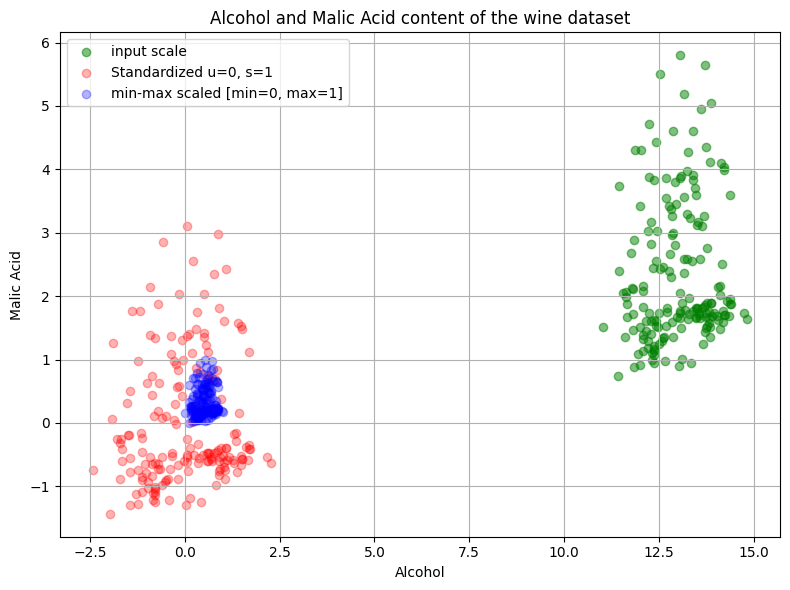

In [309]:
# 创建综合对比图：原始数据 vs Z-score标准化 vs Min-Max标准化
def plot():
    f = plt.figure(figsize=(8,6))

    # 绿色：原始数据（注意量纲差异）
    plt.scatter(df['Alcohol'], df['Malic acid'],
            color='green', label='input scale', alpha=0.5)

    # 红色：Z-score标准化（均值0，标准差1）
    plt.scatter(df_std[:,0], df_std[:,1], color='red',
             label='Standardized u=0, s=1', alpha=0.3)

    # 蓝色：Min-Max标准化（范围[0,1]）
    plt.scatter(df_minmax[:,0], df_minmax[:,1],
            color='blue', label='min-max scaled [min=0, max=1]', alpha=0.3)

    plt.title('Alcohol and Malic Acid content of the wine dataset')
    plt.xlabel('Alcohol')
    plt.ylabel('Malic Acid')
    plt.legend(loc='upper left')
    plt.grid()
    plt.tight_layout()

plot()
plt.show()

# 💡 观察：三种处理方式保持了相同的数据分布形状，只是位置和尺度不同

### 📊 三种数据版本的可视化对比
下面的散点图将展示同一数据在三种不同处理方式下的分布：
1. **绿色**：原始数据（不同量纲）
2. **红色**：Z-score标准化（均值0，标准差1）
3. **蓝色**：Min-Max标准化（范围[0,1]）

The plot above includes the wine datapoints on all three different scales:
* the input scale  where the alcohol content was measured in volume-percent (green),
* the standardized features (red), and
* the normalized features (blue).

In the following plot, we will zoom in into the three different axis-scales while dispalying class values.

#### Discussion:
- What has been changed after min-max normalisation?
- What is not changed?

### 🤔 Min-Max标准化讨论题解答

**Q1: Min-Max标准化后什么改变了？**
**A1**: 
- ✅ **数值范围**：从原始范围缩放到[0,1]
- ✅ **数据位置**：最小值变为0，最大值变为1
- ✅ **量纲统一**：所有特征都在相同范围内

**Q2: 什么没有改变？**
**A2**:
- ✅ **分布形状**：数据的分布模式保持不变
- ✅ **相对关系**：数据点之间的相对位置关系不变
- ✅ **排序**：数据的大小排序保持一致

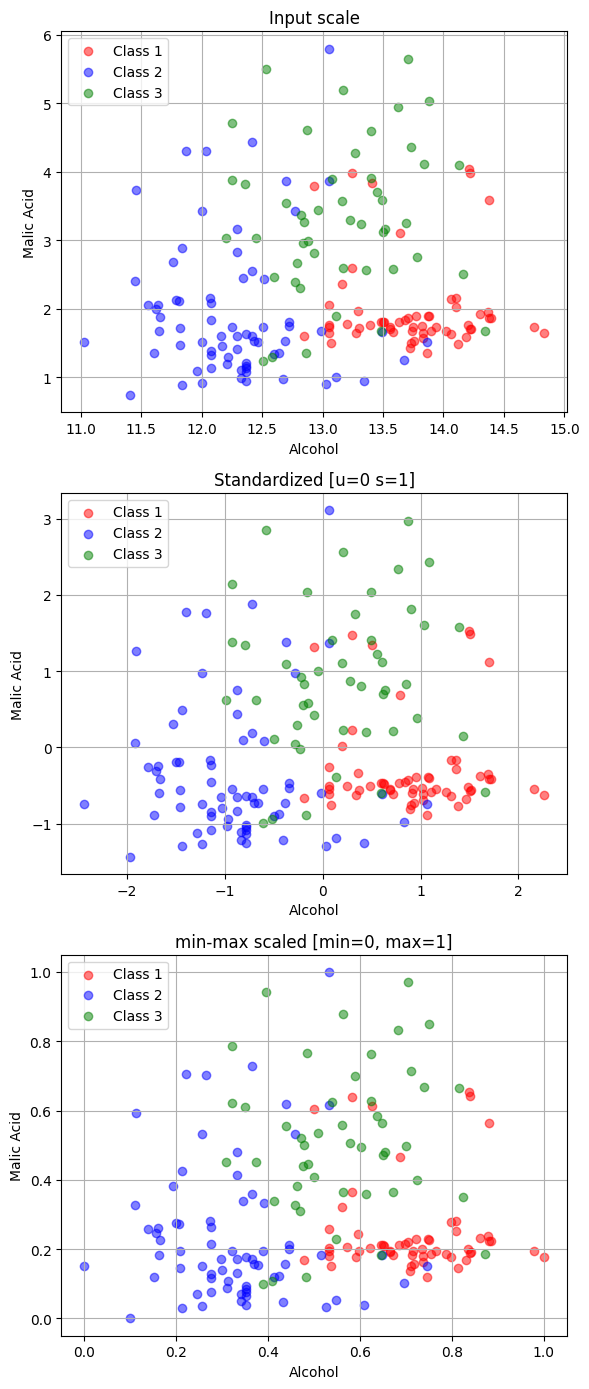

In [310]:
fig, ax = plt.subplots(3, figsize=(6,14))

for a,d,l in zip(range(len(ax)),
               (df[['Alcohol', 'Malic acid']].values, df_std, df_minmax),
               ('Input scale',
                'Standardized [u=0 s=1]',
                'min-max scaled [min=0, max=1]')
                ):
    for i,c in zip(range(1,4), ('red', 'blue', 'green')):
        ax[a].scatter(d[df['Class label'].values == i, 0],
                  d[df['Class label'].values == i, 1],
                  alpha=0.5,
                  color=c,
                  label='Class %s' %i
                  )
    ax[a].set_title(l)
    ax[a].set_xlabel('Alcohol')
    ax[a].set_ylabel('Malic Acid')
    ax[a].legend(loc='upper left')
    ax[a].grid()

plt.tight_layout()

plt.show()

### Task 2. Data Transformation:

### 📚 数据变换（Data Transformation）概述
数据变换是通过数学函数改变数据分布的技术，主要目的：
- 🎯 **减少偏态**：让数据更接近正态分布
- 🎯 **稳定方差**：减少方差的不均匀性
- 🎯 **线性化关系**：将非线性关系转换为线性关系

Another way to reshape data is to perform data transformation. We will display an example of data that is with right skew (positive skew). We will need to compress large values. We first read the data used for this activity.

In [311]:
# 读取BMR（基础代谢率）数据集用于变换实验
# 这个数据集包含动物的基础代谢率和体重数据
data = pd.read_csv("bmr.csv")
print("数据集形状:", data.shape)

数据集形状: (1006, 8)


In [312]:
data.head()

,Order,Family,Species,Mass(g),BMR(W),Speciesavg.mass(g),Speciesavg.BMR(W),References
0,Artiodactyla,Antilocapridae,Antilocapraamericana,32000.0,49.984,34779.3,50.973,Lovegrove(2000)
1,Artiodactyla,Antilocapridae,Antilocapraamericana,37800.0,51.981,NaN,NaN,White&Seymour(2003)
2,Artiodactyla,Bovidae,Bostaurus,347000.0,306.770,347000.0,306.770,Heusner(1991)
3,Artiodactyla,Bovidae,Cephalophusmonticola,4200.0,10.075,4200.0,10.075,Lovegrove(2000)
4,Artiodactyla,Bovidae,Connochaetestaurinus,196500.0,230.073,196500.0,230.073,"White&Seymour(2003),Rogerson(1968)"


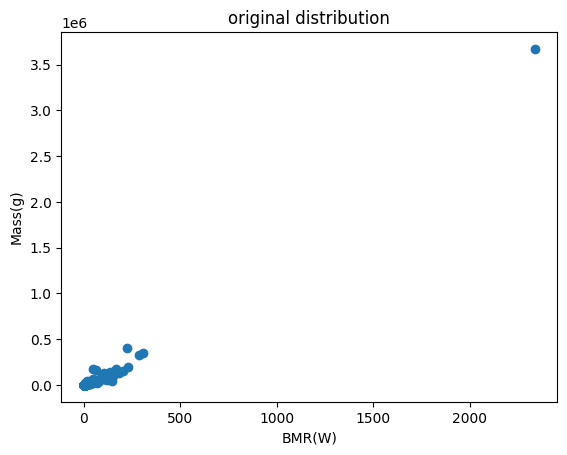

In [313]:
# 绘制原始数据的散点图
# X轴：基础代谢率(W)，Y轴：体重(g)
plt.scatter(data["BMR(W)"], data["Mass(g)"]) # before
plt.xlabel("BMR(W)") #基础代谢率
plt.ylabel("Mass(g)") #体重
plt.title("original distribution")
plt.show()

# 💡 观察：数据呈现明显的右偏分布，存在少数极大值

### Discussion:
So, which transformation type will suit this data?

### 🤔 选择合适的变换方法

**观察到的问题**：
- 数据呈现**右偏分布**（正偏态）
- 存在**少数极大值**
- 大部分数据**聚集在较小值**范围

**根据Tukey's Ladder of Powers**：
- 对于**右偏数据**，需要**向下移动**阶梯
- **压缩大值，展开小值**
- 适合的变换：**平方根、对数变换**

In Tukey's ladder of power, we discussed different kind of transformation. Here you are going to
compare the following three kinds of transformations
* Root transformation
* Square power transformation
* Log transformation

### 📊 Tukey's Ladder of Powers 复习
```
λ = 3:  x³   (立方) - 增强右偏
λ = 2:  x²   (平方) - 增强右偏  
λ = 1:  x    (原始) - 无变换
λ = 0.5: √x  (平方根) - 减少右偏
λ = 0:  log x (对数) - 减少右偏
λ = -1: 1/x  (倒数) - 减少右偏
```

**策略**：
- **右偏数据** → 向下移动（λ < 1）
- **左偏数据** → 向上移动（λ > 1）

The implementation of Root transformation is given as follows. You need to finish the other two kinds of transformation.

#### Task 2.1 Root transformation:

### 🔹 平方根变换 (λ = 0.5)
**公式**: $x' = \sqrt{x}$
**作用**: 压缩大值，展开小值，减少右偏

In [314]:
import math

# 对BMR(W)应用平方根变换
data['lmr'] = None  # lmr = log metabolic rate (这里实际是sqrt变换)
i = 0
for row in data.iterrows():
    data['lmr'].at[i] = math.sqrt(data["BMR(W)"][i])
    i += 1

data.head()

# 💡 更pythonic的写法：data['lmr'] = np.sqrt(data["BMR(W)"])

,Order,Family,Species,Mass(g),BMR(W),Speciesavg.mass(g),Speciesavg.BMR(W),References,lmr
0,Artiodactyla,Antilocapridae,Antilocapraamericana,32000.0,49.984,34779.3,50.973,Lovegrove(2000),7.069936
1,Artiodactyla,Antilocapridae,Antilocapraamericana,37800.0,51.981,NaN,NaN,White&Seymour(2003),7.209785
2,Artiodactyla,Bovidae,Bostaurus,347000.0,306.770,347000.0,306.770,Heusner(1991),17.514851
3,Artiodactyla,Bovidae,Cephalophusmonticola,4200.0,10.075,4200.0,10.075,Lovegrove(2000),3.174114
4,Artiodactyla,Bovidae,Connochaetestaurinus,196500.0,230.073,196500.0,230.073,"White&Seymour(2003),Rogerson(1968)",15.168157


In [315]:
# 对Mass(g)应用平方根变换
data['lbm'] = None  # lbm = log body mass (这里实际是sqrt变换)
i = 0
for row in data.iterrows():
    data['lbm'].at[i] = math.sqrt(data["Mass(g)"][i])
    i += 1

data.head()

# ⚡ 提示：变量名虽然叫lmr、lbm，但这里实际执行的是平方根变换

,Order,Family,Species,Mass(g),BMR(W),Speciesavg.mass(g),Speciesavg.BMR(W),References,lmr,lbm
0,Artiodactyla,Antilocapridae,Antilocapraamericana,32000.0,49.984,34779.3,50.973,Lovegrove(2000),7.069936,178.885438
1,Artiodactyla,Antilocapridae,Antilocapraamericana,37800.0,51.981,NaN,NaN,White&Seymour(2003),7.209785,194.422221
2,Artiodactyla,Bovidae,Bostaurus,347000.0,306.770,347000.0,306.770,Heusner(1991),17.514851,589.067059
3,Artiodactyla,Bovidae,Cephalophusmonticola,4200.0,10.075,4200.0,10.075,Lovegrove(2000),3.174114,64.807407
4,Artiodactyla,Bovidae,Connochaetestaurinus,196500.0,230.073,196500.0,230.073,"White&Seymour(2003),Rogerson(1968)",15.168157,443.283205


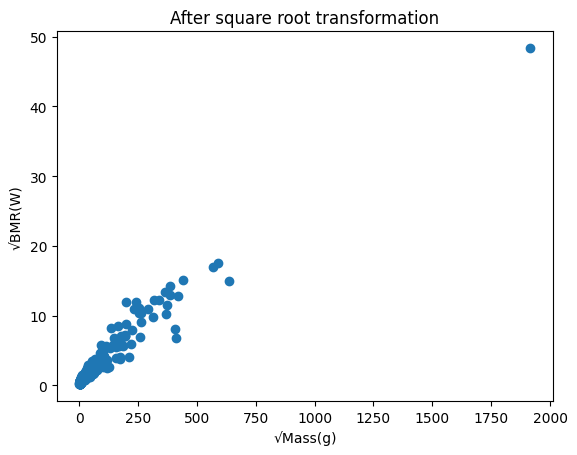

In [316]:
# 绘制平方根变换后的数据
plt.scatter(data.lbm, data.lmr) # and after
plt.xlabel("√Mass(g)") #体重平方根
plt.ylabel("√BMR(W)") #代谢率平方根
plt.title("After square root transformation")
plt.show()

# 💡 观察：数据分布变得更加线性，但仍有一定的偏态

Does it give a better spread of the data?
Let's try something else.

#### Task 2.2 Square power transformation:

### 🔹 平方变换 (λ = 2)
**公式**: $x' = x^2$
**作用**: 展开大值，压缩小值，**增强右偏**
**注意**: 对于已经右偏的数据，平方变换会**恶化**偏态！

In [317]:
import math

# 对BMR(W)应用平方变换
data['lmr'] = None
i = 0
for row in data.iterrows():
    data['lmr'].at[i] = math.pow(data["BMR(W)"][i], 2)  # x²变换
    i += 1

data.head()

# ⚠️ 注意：平方变换会让大值变得更大，进一步增强右偏特性

,Order,Family,Species,Mass(g),BMR(W),Speciesavg.mass(g),Speciesavg.BMR(W),References,lmr,lbm
0,Artiodactyla,Antilocapridae,Antilocapraamericana,32000.0,49.984,34779.3,50.973,Lovegrove(2000),2498.400256,178.885438
1,Artiodactyla,Antilocapridae,Antilocapraamericana,37800.0,51.981,NaN,NaN,White&Seymour(2003),2702.024361,194.422221
2,Artiodactyla,Bovidae,Bostaurus,347000.0,306.770,347000.0,306.770,Heusner(1991),94107.8329,589.067059
3,Artiodactyla,Bovidae,Cephalophusmonticola,4200.0,10.075,4200.0,10.075,Lovegrove(2000),101.505625,64.807407
4,Artiodactyla,Bovidae,Connochaetestaurinus,196500.0,230.073,196500.0,230.073,"White&Seymour(2003),Rogerson(1968)",52933.585329,443.283205


In [318]:
# 对Mass(g)应用平方变换
data['lbm'] = None
i = 0
for row in data.iterrows():
    data['lbm'].at[i] = math.pow(data["Mass(g)"][i], 2)  # x²变换
    i += 1

data.head()

# 💡 观察数值：平方后的数值变得非常大

,Order,Family,Species,Mass(g),BMR(W),Speciesavg.mass(g),Speciesavg.BMR(W),References,lmr,lbm
0,Artiodactyla,Antilocapridae,Antilocapraamericana,32000.0,49.984,34779.3,50.973,Lovegrove(2000),2498.400256,1024000000.0
1,Artiodactyla,Antilocapridae,Antilocapraamericana,37800.0,51.981,NaN,NaN,White&Seymour(2003),2702.024361,1428840000.0
2,Artiodactyla,Bovidae,Bostaurus,347000.0,306.770,347000.0,306.770,Heusner(1991),94107.8329,120409000000.0
3,Artiodactyla,Bovidae,Cephalophusmonticola,4200.0,10.075,4200.0,10.075,Lovegrove(2000),101.505625,17640000.0
4,Artiodactyla,Bovidae,Connochaetestaurinus,196500.0,230.073,196500.0,230.073,"White&Seymour(2003),Rogerson(1968)",52933.585329,38612250000.0


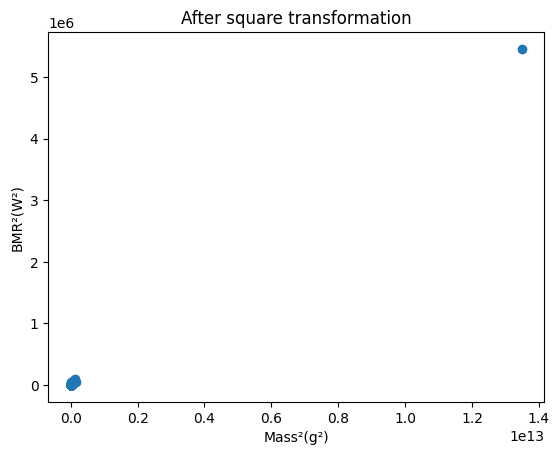

In [319]:
# 绘制平方变换后的数据
plt.scatter(data.lbm, data.lmr) # and after
plt.xlabel("Mass²(g²)")#体重平方
plt.ylabel("BMR²(W²)") #代谢率平方
plt.title("After square transformation")
plt.show()

# 💡 观察：右偏特性被严重放大，数据更加集中在左下角

#### Can you justify the output of this figure?

### 🤔 思考：为什么平方变换的结果这样？

**分析**：
1. **原始数据**：右偏分布，大部分数据聚集在小值区域
2. **平方变换效果**：
   - 小值变得更小（如：2² = 4）
   - 大值变得极大（如：100² = 10,000）
3. **结果**：右偏特性被**严重放大**

**结论**：对于右偏数据，平方变换是**错误的选择**！

#### Task 2.3 Log transformation:

### 🔹 对数变换 (λ = 0)
**公式**: $x' = \log(x)$
**作用**: 强力压缩大值，适度展开小值
**特点**: 是处理右偏数据的**经典方法**

In [320]:
import math

# 对BMR(W)应用对数变换
data['lmr'] = None
i = 0
for row in data.iterrows():
    data['lmr'].at[i] = math.log(data["BMR(W)"][i])  # 自然对数变换
    i += 1

data.head()

# 💡 对数变换将极大的数值范围压缩到相对较小的范围

,Order,Family,Species,Mass(g),BMR(W),Speciesavg.mass(g),Speciesavg.BMR(W),References,lmr,lbm
0,Artiodactyla,Antilocapridae,Antilocapraamericana,32000.0,49.984,34779.3,50.973,Lovegrove(2000),3.911703,1024000000.0
1,Artiodactyla,Antilocapridae,Antilocapraamericana,37800.0,51.981,NaN,NaN,White&Seymour(2003),3.950878,1428840000.0
2,Artiodactyla,Bovidae,Bostaurus,347000.0,306.770,347000.0,306.770,Heusner(1991),5.726098,120409000000.0
3,Artiodactyla,Bovidae,Cephalophusmonticola,4200.0,10.075,4200.0,10.075,Lovegrove(2000),2.310057,17640000.0
4,Artiodactyla,Bovidae,Connochaetestaurinus,196500.0,230.073,196500.0,230.073,"White&Seymour(2003),Rogerson(1968)",5.438397,38612250000.0


In [321]:
# 对Mass(g)应用对数变换  
data['lbm'] = None
i = 0
for row in data.iterrows():
    data['lbm'].at[i] = math.log(data["Mass(g)"][i])  # 自然对数变换
    i += 1

data.head()

# 💡 观察：对数变换后的数值范围大大缩小

,Order,Family,Species,Mass(g),BMR(W),Speciesavg.mass(g),Speciesavg.BMR(W),References,lmr,lbm
0,Artiodactyla,Antilocapridae,Antilocapraamericana,32000.0,49.984,34779.3,50.973,Lovegrove(2000),3.911703,10.373491
1,Artiodactyla,Antilocapridae,Antilocapraamericana,37800.0,51.981,NaN,NaN,White&Seymour(2003),3.950878,10.540064
2,Artiodactyla,Bovidae,Bostaurus,347000.0,306.770,347000.0,306.770,Heusner(1991),5.726098,12.75708
3,Artiodactyla,Bovidae,Cephalophusmonticola,4200.0,10.075,4200.0,10.075,Lovegrove(2000),2.310057,8.34284
4,Artiodactyla,Bovidae,Connochaetestaurinus,196500.0,230.073,196500.0,230.073,"White&Seymour(2003),Rogerson(1968)",5.438397,12.188418


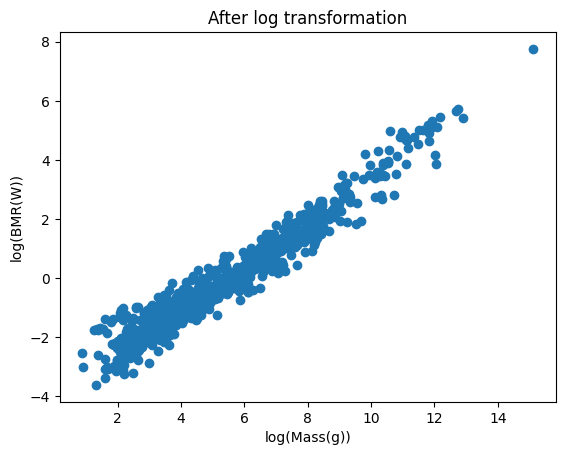

In [322]:
# 绘制对数变换后的数据
plt.scatter(data.lbm, data.lmr) # and after
plt.xlabel("log(Mass(g))") 
plt.ylabel("log(BMR(W))")
plt.title("After log transformation")
plt.show()

# 🎯 观察：数据呈现良好的线性关系，偏态问题得到很好的解决！

Apparently, the best transformation for this data is log transformation. As the data is positively skewed. we will need to compress large values. That means we need to move down the ladder of powers to spread out data that is clustered at lower values. Therefore, logarithmic is the appropriate transformation in this case.

### 🎯 变换方法总结与选择策略

**实验结果对比**：
1. **平方根变换**：部分改善，但效果有限
2. **平方变换**：恶化偏态，完全不适合
3. **对数变换**：效果最佳，数据呈现良好的线性关系

**选择原则**：
- **正偏态（右偏）数据** → 向下移动Tukey阶梯（λ < 1）
- **负偏态（左偏）数据** → 向上移动Tukey阶梯（λ > 1）
- **对数变换**是处理正偏态数据的**首选方法**

**变换效果验证**：
- ✅ 减少了偏态
- ✅ 建立了线性关系  
- ✅ 稳定了方差

Some materials used in this tutorial are based on http://sebastianraschka.com/Articles/2014_about_feature_scaling.html

#### Self-Exercise:
Consider the following dataset:

In [323]:
body_mass = [32000, 37800, 347000, 4200, 196500, 100000, 4290,
32000, 65000, 69125, 9600, 133300, 150000, 407000, 115000, 67000,
325000, 21500, 58588, 65320, 85000, 135000, 20500, 1613, 1618]

metabolic_rate = [49.984, 51.981, 306.770, 10.075, 230.073,
148.949, 11.966, 46.414, 123.287, 106.663, 20.619, 180.150,
200.830, 224.779, 148.940, 112.430, 286.847, 46.347, 142.863,
106.670, 119.660, 104.150, 33.165, 4.900, 4.865]

### 🏃‍♂️ 自主练习题解答思路

**数据特征分析**：
- body_mass: 1613-407000，范围极大
- metabolic_rate: 4.865-306.770，同样右偏

**推荐变换方法**：
1. **对数变换** - 首选，能很好处理右偏数据
2. **平方根变换** - 备选，效果次之
3. **Box-Cox变换** - 最优，通过参数优化找到最佳λ值

**验证方法**：
- 绘制变换前后的散点图
- 检查数据的偏态程度
- 观察线性关系的改善

What will be the appropriate transformation to apply for this data? Post your finds in the forum.

## 2: Data Discretization

### 📚 数据离散化（Data Discretisation）概述
**定义**：将连续数值转换为有限的离散类别或区间

**目的**：
- 🎯 **数据简化**：减少数据复杂度
- 🎯 **降噪平滑**：减少测量误差和噪声
- 🎯 **算法兼容**：某些算法只能处理类别数据
- 🎯 **可解释性**：离散类别更容易理解

**常用方法**：
1. **分箱（Binning）** - 等宽、等频分箱
2. **基于聚类** - K-means等聚类算法
3. **基于决策树** - 使用决策树分割点

### Task 2.1 Binning:
Binning aims to discretise continuous values into discrete bins. We explain in the following different ways for implementing  binning with Python.  

### 🗂️ 分箱技术详解
**分箱（Binning）**是最常用的离散化方法：

**优点**：
- ✅ 减少噪声影响
- ✅ 处理异常值
- ✅ 简化数据分析

**主要类型**：
1. **等宽分箱**：每个箱的宽度相等
2. **等频分箱**：每个箱的样本数量相等

#### 2.1.1. Using the digitize() method:

In [324]:
# 使用numpy.digitize()方法进行分箱
np.random.seed(1234) # 设置随机种子，确保结果可重现

n = 100 # 生成100个数据点
data = np.random.random(n) # 生成[0,1]区间的随机数

# 创建11个等距的分箱边界，形成10个箱子
bins = np.linspace(0, 1, 11) # equally spaced bins, from 0 to 1.0
# 11个边界点，创建10个箱子: [0,0.1), [0.1,0.2), ..., [0.9,1.0]

# 将数据分配到对应的箱子中
digitized = np.digitize(data, bins) # put the n in the b

print(f"数据点数量: {n}")
print(f"箱子数量: {len(bins)-1}")
print(f"分箱边界: {bins[:3]}...{bins[-3:]}")  # 显示前3个和后3个边界

数据点数量: 100
箱子数量: 10
分箱边界: [0.  0.1 0.2]...[0.8 0.9 1. ]


In [325]:
# 检查分箱边界
print(f"边界数量: {len(bins)}")
print(f"箱子数量: {len(bins)-1}")
print(f"分箱边界: {bins}")

# 💡 理解：11个边界创建10个箱子
# 箱子1: [0.0, 0.1), 箱子2: [0.1, 0.2), ..., 箱子10: [0.9, 1.0]

边界数量: 11
箱子数量: 10
分箱边界: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [326]:
data

array([0.19151945, 0.62210877, 0.43772774, 0.78535858, 0.77997581,
       0.27259261, 0.27646426, 0.80187218, 0.95813935, 0.87593263,
       0.35781727, 0.50099513, 0.68346294, 0.71270203, 0.37025075,
       0.56119619, 0.50308317, 0.01376845, 0.77282662, 0.88264119,
       0.36488598, 0.61539618, 0.07538124, 0.36882401, 0.9331401 ,
       0.65137814, 0.39720258, 0.78873014, 0.31683612, 0.56809865,
       0.86912739, 0.43617342, 0.80214764, 0.14376682, 0.70426097,
       0.70458131, 0.21879211, 0.92486763, 0.44214076, 0.90931596,
       0.05980922, 0.18428708, 0.04735528, 0.67488094, 0.59462478,
       0.53331016, 0.04332406, 0.56143308, 0.32966845, 0.50296683,
       0.11189432, 0.60719371, 0.56594464, 0.00676406, 0.61744171,
       0.91212289, 0.79052413, 0.99208147, 0.95880176, 0.79196414,
       0.28525096, 0.62491671, 0.4780938 , 0.19567518, 0.38231745,
       0.05387369, 0.45164841, 0.98200474, 0.1239427 , 0.1193809 ,
       0.73852306, 0.58730363, 0.47163253, 0.10712682, 0.22921

In [327]:
data.min(), data.max(), data.mean(), data.std()

(np.float64(0.006208516587129398),
 np.float64(0.9920814661883615),
 np.float64(0.5183629078788025),
 np.float64(0.27671876680061797))

In [328]:
# 显示分箱结果
print("前20个数据点的分箱结果:")
print(digitized[:20])

# 💡 digitized数组中的值表示每个数据点被分配到的箱子编号
# 值为1表示第1个箱子，值为10表示第10个箱子

前20个数据点的分箱结果:
[ 2  7  5  8  8  3  3  9 10  9  4  6  7  8  4  6  6  1  8  9]


In [329]:
# 将原始数据和分箱结果放在同一个DataFrame中便于观察
df = pd.DataFrame({"Data" : data, "DigBin" : digitized})
print("数据框的前几行:")
print(df.head())

数据框的前几行:
       Data  DigBin
0  0.191519       2
1  0.622109       7
2  0.437728       5
3  0.785359       8
4  0.779976       8


In [330]:
# 统计每个箱子中的数据点数量
bin_counts = df.DigBin.value_counts().sort_index()
print("每个箱子的数据点数量:")
print(bin_counts)

# 💡 观察：由于是随机数据，每个箱子的数据点数量大致相等（等宽分箱的特点）

每个箱子的数据点数量:
DigBin
1      9
2     10
3      5
4      9
5     10
6     15
7     12
8     12
9      8
10    10
Name: count, dtype: int64


In [331]:
df.head()

,Data,DigBin
0,0.191519,2
1,0.622109,7
2,0.437728,5
3,0.785359,8
4,0.779976,8


In [332]:
# 按原始数据值排序，观察分箱逻辑
df_sorted = df.sort_values("Data")
print("按原始数据值排序后的前10行:")
print(df_sorted.head(10))
print("\n按原始数据值排序后的后10行:")
print(df_sorted.tail(10))

# 💡 观察：最小的数据在箱子1，最大的数据在箱子10

按原始数据值排序后的前10行:
        Data  DigBin
78  0.006209       1
53  0.006764       1
17  0.013768       1
46  0.043324       1
42  0.047355       1
65  0.053874       1
98  0.057116       1
40  0.059809       1
22  0.075381       1
73  0.107127       2

按原始数据值排序后的后10行:
        Data  DigBin
39  0.909316      10
55  0.912123      10
82  0.918198      10
37  0.924868      10
24  0.933140      10
93  0.951429      10
8   0.958139      10
58  0.958802      10
67  0.982005      10
57  0.992081      10


In [333]:
# so all the little numbers ended up in bin 1, all the big ones in bin 10:
df.sort_values("DigBin").tail()

,Data,DigBin
39,0.909316,10
37,0.924868,10
24,0.933140,10
8,0.958139,10
58,0.958802,10


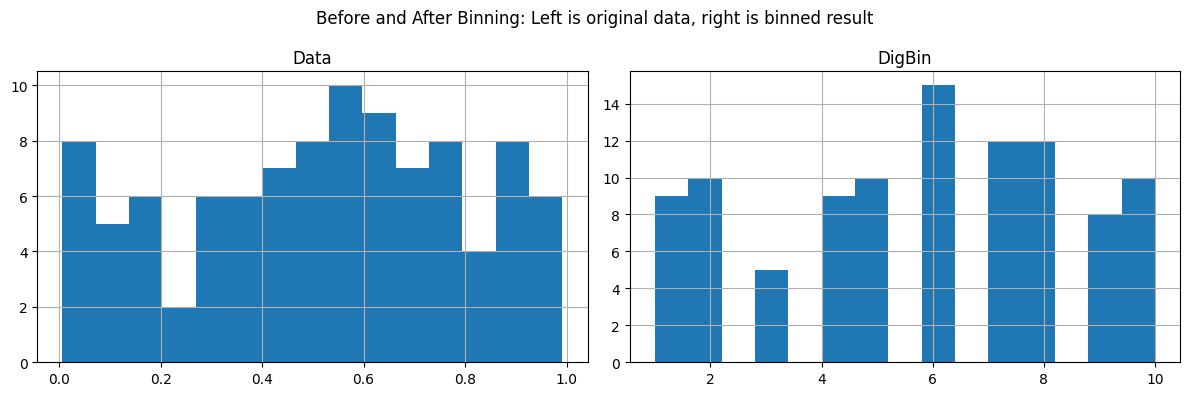

In [334]:
# 绘制分箱前后的直方图对比
df.hist(bins=15, figsize=(12, 4)) 
plt.suptitle('Before and After Binning: Left is original data, right is binned result') #分箱前后对比: 左图为原始数据，右图为分箱结果
plt.tight_layout()
plt.show()

# 💡 观察：
# - 左图：原始数据的连续分布
# - 右图：离散化后的分箱结果（x轴为箱子编号1-10）

#### 2.1.2 Histograms:
You can also use histogram to do binning for you:

### 📊 使用直方图进行分箱
**np.histogram()函数**可以同时完成分箱和统计：
- 返回每个箱的统计值（如均值、计数等）
- 更灵活的分箱统计方法

In [335]:
# 使用histogram方法计算每个箱的均值
# histogram(data, bins, weights=data) 计算加权和
# histogram(data, bins) 计算计数
# 两者相除得到每个箱的均值
binH = (np.histogram(data, bins, weights = data)[0] / np.histogram(data, bins)[0])

print("使用histogram方法计算的每个箱的均值:")
print(binH)

使用histogram方法计算的每个箱的均值:
[0.04040002 0.14799998 0.2564637  0.35427159 0.44897324 0.54339197
 0.63648436 0.75179231 0.84773691 0.94401007]


In [336]:
# 检查结果
print(f"箱子数量: {len(binH)}")
print(f"每个箱的均值: {binH}")

# 💡 binH包含每个箱中数据的均值，可以用来代替原始数据进行平滑

箱子数量: 10
每个箱的均值: [0.04040002 0.14799998 0.2564637  0.35427159 0.44897324 0.54339197
 0.63648436 0.75179231 0.84773691 0.94401007]


#### 2.1.3 Using scipy:

### 🔬 使用SciPy进行高级分箱
**scipy.stats.binned_statistic()** 提供更灵活的分箱统计功能：
- 可以计算不同的统计量（均值、中位数、计数等）
- 返回详细的分箱信息

In [337]:
# 使用scipy的binned_statistic进行分箱
from scipy.stats import binned_statistic

# 计算每个箱的均值（默认统计量）
binS = binned_statistic(data, data, bins = 10, range = (0, 1))[0]
print("SciPy binned_statistic结果:")
print(binS)

SciPy binned_statistic结果:
[0.04040002 0.14799998 0.2564637  0.35427159 0.44897324 0.54339197
 0.63648436 0.75179231 0.84773691 0.94401007]


##### Discussion:
- What is binned_statistic doing?
- bin_count, bin_edges, bin_number

### 🤔 binned_statistic函数详解

**binned_statistic功能**：
- 将数据分箱并计算每个箱的统计量
- 默认计算均值，也可以计算count、median、std等

**返回值解释**：
- **bin_count**: 每个箱中的数据点数量
- **bin_edges**: 箱的边界值
- **bin_number**: 每个数据点所属的箱编号

In [338]:
# ?binned_statistic

In [147]:
# 使用binned_statistic计算每个箱的数据点数量
bc, be, bn = binned_statistic(data, data, statistic = 'count', bins = 10)

print("bin_count (每个箱的数据点数量):")
print(bc)
print(f"\n总数据点: {bc.sum()}")  # 应该等于100

bin_count (每个箱的数据点数量):
[ 9. 10.  6.  8. 10. 15. 12. 12.  7. 11.]

总数据点: 100.0


In [148]:
bc #, bc.sum() # =100

array([ 9., 10.,  6.,  8., 10., 15., 12., 12.,  7., 11.])

In [149]:
# 显示箱边界
print("bin_edges (箱边界):")
print(be)
print(f"\n边界数量: {len(be)}")
print(f"箱子数量: {len(be)-1}")

# 💡 注意：边界可能不是完全整齐的数字，这是因为浮点数精度问题

bin_edges (箱边界):
[0.00620852 0.10479581 0.20338311 0.3019704  0.4005577  0.49914499
 0.59773229 0.69631958 0.79490688 0.89349417 0.99208147]

边界数量: 11
箱子数量: 10


In [339]:
# 显示每个数据点的箱编号
print("bin_number (前20个数据点的箱编号):")
print(bn[:20])
print(f"\n箱编号范围: {bn.min()} - {bn.max()}")

# 💡 bin_number表示每个数据点被分配到的箱子编号

bin_number (前20个数据点的箱编号):
[ 2  7  5  8  8  3  3  9 10  9  4  6  7  8  4  6  6  1  8  9]

箱编号范围: 1 - 10


In [340]:
# 将SciPy的分箱结果添加到DataFrame中进行对比
df["SciBin"] = bn # put side by side with the previous df
print("对比不同分箱方法:")
print(df.head(10))

对比不同分箱方法:
       Data  DigBin  SciBin
0  0.191519       2       2
1  0.622109       7       7
2  0.437728       5       5
3  0.785359       8       8
4  0.779976       8       8
5  0.272593       3       3
6  0.276464       3       3
7  0.801872       9       9
8  0.958139      10      10
9  0.875933       9       9


In [341]:
# 按原始数据排序，观察两种分箱方法的差异
df_sorted = df.sort_values("Data")
print("按数据值排序，对比两种分箱方法:")
print(df_sorted.head(15))

# 💡 观察DigBin和SciBin列的差异

按数据值排序，对比两种分箱方法:
        Data  DigBin  SciBin
78  0.006209       1       1
53  0.006764       1       1
17  0.013768       1       1
46  0.043324       1       1
42  0.047355       1       1
65  0.053874       1       1
98  0.057116       1       1
40  0.059809       1       1
22  0.075381       1       1
73  0.107127       2       2
50  0.111894       2       2
69  0.119381       2       2
68  0.123943       2       2
33  0.143767       2       2
85  0.149834       2       2


array([[<Axes: title={'center': 'Data'}>,
        <Axes: title={'center': 'DigBin'}>],
       [<Axes: title={'center': 'SciBin'}>, <Axes: >]], dtype=object)

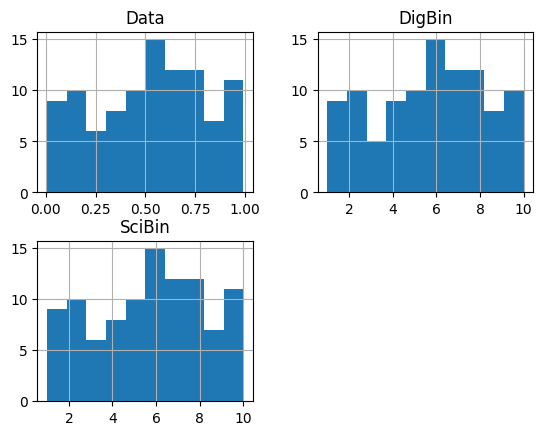

In [342]:
df.hist() # before and after again

(<Axes: >, <Axes: >)

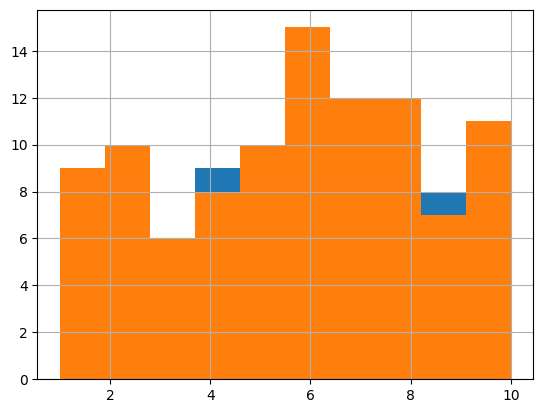

In [343]:
df.DigBin.hist(), df.SciBin.hist() # couple of blue peekers

(<Axes: >, <Axes: >)

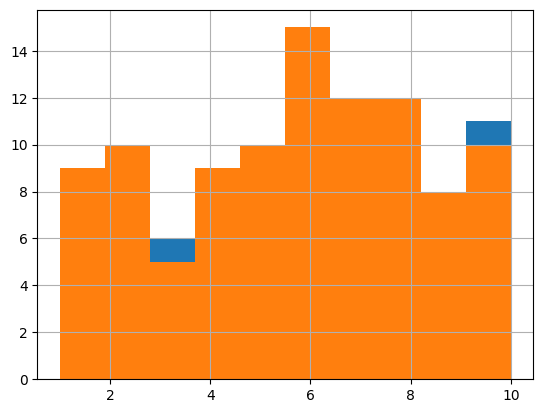

In [344]:
# do it the other way
df.SciBin.hist() ,df.DigBin.hist()

Check out http://docs.scipy.org/doc/numpy/reference/generated/numpy.digitize.html and http://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binned_statistic.html
to find out why the return values are different.

### 🔍 numpy.digitize vs scipy.binned_statistic 差异分析

**主要差异**：
1. **边界处理**：
   - `np.digitize`: 左开右闭区间，箱编号从1开始
   - `scipy.binned_statistic`: 左闭右开区间，箱编号从1开始

2. **功能差异**：
   - `np.digitize`: 只返回分箱编号
   - `scipy.binned_statistic`: 返回统计值、边界、编号

3. **精度差异**：
   - 由于浮点数精度和边界处理方式不同，结果可能略有差异

#### 2.1.4 Using Pandas Cut (Case study of ages dataset)

### 🐼 使用Pandas进行分箱
**pandas.cut()** 是最用户友好的分箱工具：
- 支持自定义分箱边界
- 支持自定义标签
- 返回易于理解的类别数据

In [345]:
# 年龄数据案例
ages = [20, 22, 25, 26, 21, 23, 37, 31, 61, 45, 41, 32]
print(f"年龄数据: {ages}")
print(f"年龄范围: {min(ages)} - {max(ages)}岁")

年龄数据: [20, 22, 25, 26, 21, 23, 37, 31, 61, 45, 41, 32]
年龄范围: 20 - 61岁


In [346]:
# 定义年龄分组：青年(18-25)、青壮年(26-35)、中年(36-60)、老年(61-100)
bins = [18, 25, 35, 60, 100] # 5个边界创建4个年龄组
cats = pd.cut(ages, bins)
print("年龄分组结果:")
print(cats)

# 💡 观察输出格式：(18, 25] 表示18<年龄≤25的区间

年龄分组结果:
[(18, 25], (18, 25], (18, 25], (25, 35], (18, 25], ..., (25, 35], (60, 100], (35, 60], (35, 60], (25, 35]]
Length: 12
Categories (4, interval[int64, right]): [(18, 25] < (25, 35] < (35, 60] < (60, 100]]


In [347]:
# cats是一个特殊的Categorical对象，包含丰富的信息
print(f"数据类型: {type(cats)}")
print(f"总数据量: {len(cats)}")
print(f"分类数量: {len(cats.categories)}")

# 显示分组类别
print(f"分组类别: {cats.categories.tolist()}")

数据类型: <class 'pandas.core.arrays.categorical.Categorical'>
总数据量: 12
分类数量: 4
分组类别: [Interval(18, 25, closed='right'), Interval(25, 35, closed='right'), Interval(35, 60, closed='right'), Interval(60, 100, closed='right')]


In [348]:
# 查看数值编码：0代表第一个分组，3代表最后一个分组
print("分组的数值编码:")
print(cats.codes)
print("\n编码对应关系:")
for i, category in enumerate(cats.categories):
    print(f"编码 {i}: {category}")

分组的数值编码:
[0 0 0 1 0 0 2 1 3 2 2 1]

编码对应关系:
编码 0: (18, 25]
编码 1: (25, 35]
编码 2: (35, 60]
编码 3: (60, 100]


In [349]:
cats.categories # the names, note the use of '(' and ']'
# '(' means open, '[' means closed, or inclusive, exclusive

IntervalIndex([(18, 25], (25, 35], (35, 60], (60, 100]], dtype='interval[int64, right]')

In [350]:
# 统计每个年龄组的人数
age_counts = pd.value_counts(cats)
print("各年龄组人数统计:")
print(age_counts)

# 💡 可以看到只有1个人在60-100岁组，大部分人在青年和青壮年组

各年龄组人数统计:
(18, 25]     5
(25, 35]     3
(35, 60]     3
(60, 100]    1
Name: count, dtype: int64


/var/folders/jb/gyj0mskn1d5bh5qgnqp4zn0w0000gn/T/ipykernel_13197/3434552822.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  age_counts = pd.value_counts(cats)


which side is closed can be changed

In [351]:
# 更改区间的开闭性：right=True表示右闭区间
cats2 = pd.cut(ages, [18, 26, 36, 61, 100], right = True)
print("调整边界后的分组:")
print(pd.value_counts(cats2))

# 💡 现在26岁被分到18-26组，61岁被分到36-61组

调整边界后的分组:
(18, 26]     6
(36, 61]     4
(26, 36]     2
(61, 100]    0
Name: count, dtype: int64


/var/folders/jb/gyj0mskn1d5bh5qgnqp4zn0w0000gn/T/ipykernel_13197/3512432048.py:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(cats2))


In [352]:
pd.value_counts(cats2) # now 26 is in 18 - 26, 61 is in 36 - 61

/var/folders/jb/gyj0mskn1d5bh5qgnqp4zn0w0000gn/T/ipykernel_13197/194962941.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(cats2) # now 26 is in 18 - 26, 61 is in 36 - 61


(18, 26]     6
(36, 61]     4
(26, 36]     2
(61, 100]    0
Name: count, dtype: int64

In [353]:
# 使用自定义标签让结果更易理解
group_names = ['Youth', 'YoungAdult', 'MiddleAged', 'Senior']
cats = pd.cut(ages, bins, labels = group_names)
print("使用自定义标签的分组结果:")
print(cats)

# 💡 现在结果更直观：Youth、YoungAdult等标签比数字区间更容易理解

使用自定义标签的分组结果:
['Youth', 'Youth', 'Youth', 'YoungAdult', 'Youth', ..., 'YoungAdult', 'Senior', 'MiddleAged', 'MiddleAged', 'YoungAdult']
Length: 12
Categories (4, object): ['Youth' < 'YoungAdult' < 'MiddleAged' < 'Senior']


If you pass cut an integer number of bins instead of explicit bin edges, it will compute equal-length bins based on the minimum and maximum values in the data. Consider the case of some uniformly distributed data chopped into tenths
same data as above, 100 randoms

### ⚙️ 自动等宽分箱
当传入整数而不是具体边界时，`pd.cut()`会自动创建等宽分箱：

In [354]:
# 使用pandas.cut进行自动等宽分箱
bincut_result = pd.cut(data, 10, precision = 5)
print("自动等宽分箱结果（前10个）:")
print(bincut_result[:10])
print(f"\n分箱类别:")
print(bincut_result.categories)

自动等宽分箱结果（前10个）:
[(0.1048, 0.20338], (0.59773, 0.69632], (0.40056, 0.49914], (0.69632, 0.79491], (0.69632, 0.79491], (0.20338, 0.30197], (0.20338, 0.30197], (0.79491, 0.89349], (0.89349, 0.99208], (0.79491, 0.89349]]
Categories (10, interval[float64, right]): [(0.0052226, 0.1048] < (0.1048, 0.20338] < (0.20338, 0.30197] < (0.30197, 0.40056] ... (0.59773, 0.69632] < (0.69632, 0.79491] < (0.79491, 0.89349] < (0.89349, 0.99208]]

分箱类别:
IntervalIndex([(0.0052226, 0.1048],   (0.1048, 0.20338],  (0.20338, 0.30197],
                (0.30197, 0.40056],  (0.40056, 0.49914],  (0.49914, 0.59773],
                (0.59773, 0.69632],  (0.69632, 0.79491],  (0.79491, 0.89349],
                (0.89349, 0.99208]],
              dtype='interval[float64, right]')


In [355]:
bincut = pd.cut(data, 10, precision = 5)

In [356]:
# 获取数值编码（注意：pandas从0开始编码，numpy.digitize从1开始）
print("Pandas cut的数值编码:")
print(bincut_result.codes[:20])
print(f"编码范围: {bincut_result.codes.min()} - {bincut_result.codes.max()}")

# ⚠️ 注意：pandas编码是0-9，而numpy.digitize是1-10

Pandas cut的数值编码:
[1 6 4 7 7 2 2 8 9 8 3 5 6 7 3 5 5 0 7 8]
编码范围: 0 - 9


In [357]:
df.head()

,Data,DigBin,SciBin
0,0.191519,2,2
1,0.622109,7,7
2,0.437728,5,5
3,0.785359,8,8
4,0.779976,8,8


In [358]:
# 调整编码使其与numpy.digitize一致（+1）
adjusted_codes = bincut_result.codes + 1
print("调整后的编码（与numpy一致）:")
print(adjusted_codes[:20])
print(f"调整后编码范围: {adjusted_codes.min()} - {adjusted_codes.max()}")

调整后的编码（与numpy一致）:
[ 2  7  5  8  8  3  3  9 10  9  4  6  7  8  4  6  6  1  8  9]
调整后编码范围: 1 - 10


In [359]:
# 将pandas cut结果添加到DataFrame中
df['BinCut'] = bincut_result.codes + 1
print("对比三种分箱方法:")
print(df.head(10))

对比三种分箱方法:
       Data  DigBin  SciBin  BinCut
0  0.191519       2       2       2
1  0.622109       7       7       7
2  0.437728       5       5       5
3  0.785359       8       8       8
4  0.779976       8       8       8
5  0.272593       3       3       3
6  0.276464       3       3       3
7  0.801872       9       9       9
8  0.958139      10      10      10
9  0.875933       9       9       9


In [360]:
df.head() # are they the same?

,Data,DigBin,SciBin,BinCut
0,0.191519,2,2,2
1,0.622109,7,7,7
2,0.437728,5,5,5
3,0.785359,8,8,8
4,0.779976,8,8,8


array([[<Axes: title={'center': 'Data'}>,
        <Axes: title={'center': 'DigBin'}>],
       [<Axes: title={'center': 'SciBin'}>,
        <Axes: title={'center': 'BinCut'}>]], dtype=object)

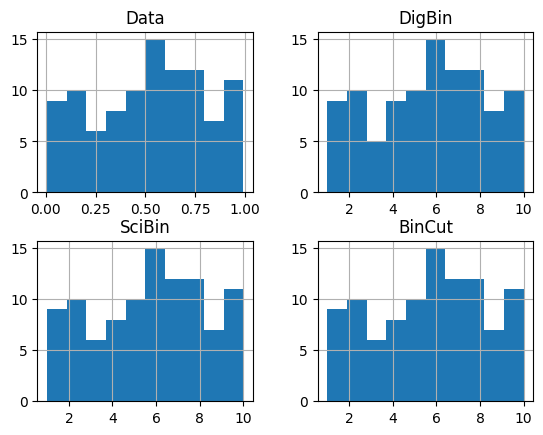

In [361]:
df.hist()

A closely related function, qcut, bins the data based on sample quantiles. Depending on the distribution of the data, using cut  will not usually result in each bin having the
same number of data points. Since qcut  uses sample quantiles instead, by definition
you will obtain roughly equal-size bins:

### 📊 等频分箱：pandas.qcut()
**pd.qcut()** 基于分位数进行分箱：
- **等频分箱**：每个箱包含相同数量的数据点
- **vs pd.cut()**：cut是等宽分箱，qcut是等频分箱
- **优势**：确保每个箱有足够的样本用于分析

In [362]:
# 使用qcut进行四分位数分箱（4个等频箱）
catsq = pd.qcut(data, 4) # Cut into quartiles
print("四分位数分箱结果:")
print(catsq.categories)
print(f"\n每个分位数的边界值:")
for i, cat in enumerate(catsq.categories):
    print(f"Q{i+1}: {cat}")

四分位数分箱结果:
IntervalIndex([(0.00521, 0.313], (0.313, 0.536], (0.536, 0.74], (0.74, 0.992]], dtype='interval[float64, right]')

每个分位数的边界值:
Q1: (0.00521, 0.313]
Q2: (0.313, 0.536]
Q3: (0.536, 0.74]
Q4: (0.74, 0.992]


In [363]:
# 验证等频分箱：每个箱应该有相同数量的数据点
quartile_counts = pd.value_counts(catsq)
print("四分位数分箱的数据点分布:")
print(quartile_counts)

# 💡 期望：每个分位数有25个数据点（100/4=25）

四分位数分箱的数据点分布:
(0.00521, 0.313]    25
(0.313, 0.536]      25
(0.536, 0.74]       25
(0.74, 0.992]       25
Name: count, dtype: int64


/var/folders/jb/gyj0mskn1d5bh5qgnqp4zn0w0000gn/T/ipykernel_13197/3033439514.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  quartile_counts = pd.value_counts(catsq)


In [364]:
catsq

[(0.00521, 0.313], (0.536, 0.74], (0.313, 0.536], (0.74, 0.992], (0.74, 0.992], ..., (0.313, 0.536], (0.536, 0.74], (0.74, 0.992], (0.00521, 0.313], (0.536, 0.74]]
Length: 100
Categories (4, interval[float64, right]): [(0.00521, 0.313] < (0.313, 0.536] < (0.536, 0.74] < (0.74, 0.992]]

In [365]:
# 验证边界值与数据的关系
print(f"数据最小值: {data.min():.6f}")
print(f"第一个分位数最小边界: {catsq.categories[0].left:.6f}")
print("✓ 最小值匹配")

print(f"\n数据最大值: {data.max():.6f}")  
print(f"最后一个分位数最大边界: {catsq.categories[-1].right:.6f}")
print("✓ 最大值匹配")

数据最小值: 0.006209
第一个分位数最小边界: 0.005210
✓ 最小值匹配

数据最大值: 0.992081
最后一个分位数最大边界: 0.992000
✓ 最大值匹配


In [366]:
# 使用自定义分位数进行分箱
custom_quantiles = pd.qcut(data, [0, 0.1, 0.5, 0.9, 1.])
print("自定义分位数分箱 (10%, 50%, 90%):")
print(custom_quantiles.categories)

# 💡 解释：
# [0, 0.1]: 最小的10%数据
# [0.1, 0.5]: 10%-50%的数据（40%）  
# [0.5, 0.9]: 50%-90%的数据（40%）
# [0.9, 1.]: 最大的10%数据

自定义分位数分箱 (10%, 50%, 90%):
IntervalIndex([(0.00521, 0.111], (0.111, 0.536], (0.536, 0.901],
               (0.901, 0.992]],
              dtype='interval[float64, right]')


In [367]:
# 验证自定义分位数的数据分布
custom_counts = pd.value_counts(pd.qcut(data, [0, 0.1, 0.5, 0.9, 1.]))
print("自定义分位数的数据点分布:")
print(custom_counts)

# 💡 预期分布：10个(10%) + 40个(40%) + 40个(40%) + 10个(10%) = 100个

自定义分位数的数据点分布:
(0.111, 0.536]      40
(0.536, 0.901]      40
(0.00521, 0.111]    10
(0.901, 0.992]      10
Name: count, dtype: int64


/var/folders/jb/gyj0mskn1d5bh5qgnqp4zn0w0000gn/T/ipykernel_13197/1992254540.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  custom_counts = pd.value_counts(pd.qcut(data, [0, 0.1, 0.5, 0.9, 1.]))


## 3: Data Sampling
Here we discuss data sampling. Simple Random Sampling methods are easy to implement. We focus in this exercise on Stratified sampling.

We load wine.csv file, please note this wine data is different from the one used later in this module.

### 📊 数据采样（Data Sampling）概述

**数据采样的目的**：
- 🎯 **减少数据量**：处理大规模数据集
- 🎯 **平衡类别**：解决类别不平衡问题  
- 🎯 **创建数据集**：分割训练/验证/测试集
- 🎯 **提高效率**：减少计算时间和内存使用

**主要采样方法**：
1. **简单随机采样（Simple Random Sampling）**
2. **分层采样（Stratified Sampling）**
3. **系统采样（Systematic Sampling）**
4. **聚类采样（Cluster Sampling）**

In [368]:
# 加载葡萄酒质量数据集（注意：这与之前的wine_data.csv不同）
wine = pd.read_csv("wine.csv")
print(f"数据集形状: {wine.shape}")
print("\n数据集前几行:")
wine.head()

数据集形状: (6497, 15)

数据集前几行:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color,is_red,high_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,1.0,0.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,1.0,0.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,1.0,0.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,1.0,0.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,1.0,0.0


In [369]:
wine.shape

(6497, 15)

In [370]:
# 查看葡萄酒质量的分布情况
quality_dist = wine.quality.value_counts().sort_index()
print("葡萄酒质量分布（原始数据）:")
print(quality_dist)

# 💡 观察：数据存在类别不平衡，质量为6的葡萄酒最多

葡萄酒质量分布（原始数据）:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


Let's take the first 50 records for easy demonstration.

In [371]:
# 为了演示方便，取前100条记录
wine = wine.iloc[0:100,:]
print(f"采样后数据形状: {wine.shape}")
print("采样范围: 前100条记录")

采样后数据形状: (100, 15)
采样范围: 前100条记录


In [372]:
# 查看取样后的质量分布
quality_dist_sample = wine.quality.value_counts().sort_index()
print("葡萄酒质量分布（前100条）:")
print(quality_dist_sample)
print(f"\n总样本数: {quality_dist_sample.sum()}")

# 💡 现在我们有100个样本，分布在不同质量等级中

葡萄酒质量分布（前100条）:
quality
4     7
5    66
6    22
7     5
Name: count, dtype: int64

总样本数: 100


### Task 3.1 Random sampling:  

Let's take a random sample of 25 records.

### 🎲 简单随机采样
**特点**：每个样本被选中的概率相等
**优点**：简单易实现，无偏估计
**缺点**：可能破坏重要子群的比例关系

In [373]:
# 进行50%的随机采样
random_sample = wine.sample(frac=0.5)
random_quality_dist = random_sample.quality.value_counts().sort_index()

print("随机采样后的质量分布:")
print(random_quality_dist)
print(f"\n随机采样大小: {len(random_sample)}")

# 🔍 对比原始分布
print("\n原始分布 vs 随机采样分布:")
comparison = pd.DataFrame({
    '原始': quality_dist_sample,
    '随机采样': random_quality_dist
}).fillna(0).astype(int)
comparison['差异'] = comparison['随机采样'] - comparison['原始']/2  # 期望值是原始的一半
print(comparison)

随机采样后的质量分布:
quality
4     3
5    33
6    13
7     1
Name: count, dtype: int64

随机采样大小: 50

原始分布 vs 随机采样分布:
         原始  随机采样   差异
quality               
4         7     3 -0.5
5        66    33  0.0
6        22    13  2.0
7         5     1 -1.5


#### Discussion:
What did you find ?

### 🤔 随机采样结果讨论

**发现的问题**：
1. **比例失衡**：随机采样可能无法保持原始数据的类别比例
2. **小类别丢失**：稀少类别可能在采样中完全消失
3. **代表性不足**：采样结果可能不能很好代表总体

**例如**：
- 原始数据中质量为5的葡萄酒有X个
- 随机采样后可能变成0个或比例严重失调

**解决方案**：使用分层采样保持类别比例！

### Task 3.2 Stratified sampling:  

Now we can take another random sample stratified by quality.

### 🎯 分层采样（Stratified Sampling）
**原理**：按照某个重要特征（如类别）将数据分层，然后在每层内进行随机采样

**优点**：
- ✅ **保持比例**：维持各类别的原始比例
- ✅ **代表性强**：确保每个重要子群都有代表
- ✅ **降低方差**：提高估计的精确度

**适用场景**：
- 类别不平衡数据
- 需要保持子群比例的研究
- 机器学习的训练/测试集划分

In [374]:
# 使用sklearn进行分层采样分割
from sklearn.model_selection import StratifiedShuffleSplit

# 创建分层分割对象
# n_splits=1: 只分割一次
# test_size=0.5: 测试集占50%
# random_state=0: 设置随机种子确保结果可重现
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=0)

# 执行分层分割
# 第一个参数：特征数据（这里用quality作为分层依据）  
# 第二个参数：标签数据（也是quality，用于分层）
sample = sss.split(wine.quality, wine.quality)

print("分层采样对象创建完成")
print(f"分割次数: 1")
print(f"测试集比例: 50%")

分层采样对象创建完成
分割次数: 1
测试集比例: 50%


We can first print the indexes, and then store the data

In [375]:
# 获取分层采样的索引并创建训练集和测试集
for train_index, test_index in sample:
    print("=== 分层采样结果 ===")
    print(f"训练集索引前10个: {train_index[:10]}")
    print(f"测试集索引前10个: {test_index[:10]}")
    print(f"训练集大小: {len(train_index)}")
    print(f"测试集大小: {len(test_index)}")
    
    # 根据索引创建训练集和测试集
    xtrain = wine.iloc[train_index]
    xtest = wine.iloc[test_index]

print("\n✅ 数据集分割完成！")

=== 分层采样结果 ===
训练集索引前10个: [99 66 32 84 55 49 35 46 83 16]
测试集索引前10个: [28  3 15 26 22 51 17 70 11 47]
训练集大小: 50
测试集大小: 50

✅ 数据集分割完成！


Now let's check the two samples xtrain and xtest.

In [376]:
# 检查训练集的形状
print(f"训练集形状: {xtrain.shape}")
print(f"训练集包含 {xtrain.shape[0]} 个样本，{xtrain.shape[1]} 个特征")

训练集形状: (50, 15)
训练集包含 50 个样本，15 个特征


In [377]:
# 检查测试集的形状
print(f"测试集形状: {xtest.shape}")
print(f"测试集包含 {xtest.shape[0]} 个样本，{xtest.shape[1]} 个特征")

# ✅ 确认：训练集和测试集大小相等（各50%）

测试集形状: (50, 15)
测试集包含 50 个样本，15 个特征


Same shape

In [378]:
# 检查训练集的质量分布
train_quality_dist = xtrain.quality.value_counts().sort_index()
print("训练集质量分布:")
print(train_quality_dist)

训练集质量分布:
quality
4     4
5    33
6    11
7     2
Name: count, dtype: int64


In [379]:
# 检查测试集的质量分布
test_quality_dist = xtest.quality.value_counts().sort_index()
print("测试集质量分布:")
print(test_quality_dist)

# 🎯 关键验证：训练集和测试集应该有相同的分布比例

测试集质量分布:
quality
4     3
5    33
6    11
7     3
Name: count, dtype: int64


Same qualif=ty distribution

In [380]:
# 验证分层采样的效果：比较原始、训练集、测试集的分布
distribution_comparison = pd.DataFrame({
    '原始数据': quality_dist_sample,
    '训练集': train_quality_dist, 
    '测试集': test_quality_dist
}).fillna(0).astype(int)

# 计算比例
distribution_comparison['原始比例'] = distribution_comparison['原始数据'] / distribution_comparison['原始数据'].sum()
distribution_comparison['训练比例'] = distribution_comparison['训练集'] / distribution_comparison['训练集'].sum()  
distribution_comparison['测试比例'] = distribution_comparison['测试集'] / distribution_comparison['测试集'].sum()

print("📊 分层采样效果验证:")
print(distribution_comparison.round(3))

# ✅ 理想情况：三列比例应该几乎相等

📊 分层采样效果验证:
         原始数据  训练集  测试集  原始比例  训练比例  测试比例
quality                                  
4           7    4    3  0.07  0.08  0.06
5          66   33   33  0.66  0.66  0.66
6          22   11   11  0.22  0.22  0.22
7           5    2    3  0.05  0.04  0.06


In [381]:
# 查看训练集的前5行数据
print("训练集前5行:")
xtrain.head()

训练集前5行:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color,is_red,high_quality
99,8.1,0.545,0.18,1.9,0.080,13.0,35.0,0.9972,3.30,0.59,9.0,6,red,1.0,0.0
66,7.5,0.520,0.11,1.5,0.079,11.0,39.0,0.9968,3.42,0.58,9.6,5,red,1.0,0.0
32,8.3,0.655,0.12,2.3,0.083,15.0,113.0,0.9966,3.17,0.66,9.8,5,red,1.0,0.0
84,6.3,0.300,0.48,1.8,0.069,18.0,61.0,0.9959,3.44,0.78,10.3,6,red,1.0,0.0
55,7.7,0.620,0.04,3.8,0.084,25.0,45.0,0.9978,3.34,0.53,9.5,5,red,1.0,0.0


In [ ]:
# 查看测试集的前5行数据
print("测试集前5行:")
xtest.head()

# 💡 观察：训练集和测试集包含不同的数据样本（没有重叠）

测试集前5行:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color,is_red,high_quality
28,7.1,0.71,0.00,1.9,0.080,14.0,35.0,0.9972,3.47,0.55,9.4,5,red,1.0,0.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,1.0,0.0
15,8.9,0.62,0.19,3.9,0.170,51.0,148.0,0.9986,3.17,0.93,9.2,5,red,1.0,0.0
26,7.6,0.41,0.24,1.8,0.080,4.0,11.0,0.9962,3.28,0.59,9.5,5,red,1.0,0.0
22,7.9,0.43,0.21,1.6,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5,red,1.0,0.0


Different data!

#### Discussion:
What is your observation of the output? Do you think these samples represent the data correctly?

### 🎯 分层采样结果讨论与分析

**观察结果**：
1. **✅ 相同的分布比例**：训练集和测试集保持了与原始数据相同的质量分布比例
2. **✅ 无数据重叠**：训练集和测试集包含完全不同的样本  
3. **✅ 代表性强**：每个质量等级在两个集合中都有适当的代表

**分层采样的优势验证**：
- **vs 简单随机采样**：不会丢失稀有类别
- **vs 原始数据**：保持了相同的统计特性
- **机器学习友好**：训练和测试集有相同的分布

**结论**：✅ 这些样本能够很好地代表原始数据！

**实际应用价值**：
- 🔬 **研究可靠**：确保统计推断的有效性
- 🤖 **模型准确**：避免训练/测试分布不一致
- 📊 **分析公正**：每个子群都得到公平代表

Check this link for more details about Stratified sampling: http://scikit-learn.org/stable/modules/generated/sklearn.cross_validation.StratifiedShuffleSplit.html

## 🎓 Week 9 总结与要点回顾

### 📚 本周学习内容总结：

#### 1️⃣ **数据标准化（Data Normalisation）**
- **Z-Score标准化**：均值0，标准差1，适合正态分布
- **Min-Max标准化**：缩放到[0,1]，保持分布形状
- **选择策略**：根据数据分布和算法需求选择

#### 2️⃣ **数据变换（Data Transformation）**  
- **Tukey's Ladder of Powers**：根据偏态选择合适的λ值
- **对数变换**：处理右偏数据的首选方法
- **Box-Cox变换**：自动寻找最优变换参数

#### 3️⃣ **数据离散化（Data Discretisation）**
- **等宽分箱**：固定区间宽度，适合均匀分布
- **等频分箱**：固定样本数量，确保统计显著性
- **工具选择**：pandas.cut vs pandas.qcut

#### 4️⃣ **数据采样（Data Sampling）**
- **简单随机采样**：简单但可能破坏比例
- **分层采样**：保持子群比例，提高代表性
- **应用场景**：训练/测试集划分，类别平衡

### 💡 **关键要点**：
1. **数据预处理是机器学习成功的基础**
2. **选择方法要根据数据特征和目标任务**
3. **验证预处理效果是必要步骤**
4. **保持数据的代表性和完整性**